<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [25]:
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Import pandas module


In [26]:
import pandas as pd


Import matplotlib


In [27]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [28]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [29]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [30]:
# Count the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicate_count}\n")

# Display the first few duplicate rows

# df[df.duplicated()] returns only those rows that are “redundant” duplicates. If a row appears three times in the dataset, this code will return only the second and third occurrences, ignoring the original (the first occurrence).
df[df.duplicated()].head(2)

# To see ALL rows that have duplicates (along with their originals): Use keep=False.
# df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6)


Number of duplicate rows in the dataset: 20



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [31]:

# Find repeating combinations of three columns,
# Check whether any other columns in those groups are also the same.

# 1. Define the columns used to identify repeated response patterns.
#    We group rows that have the same values in these three fields.
subset = ['MainBranch', 'Employment', 'RemoteWork']

# 2. Group the data by those three columns.
#    .groupby(subset) creates groups with identical combinations of values.
#    .size() counts how many rows are in each group.
#    .reset_index(name='count') turns the result into a table and names the count column 'count'.
#    .query('count > 1') keeps only groups that appear more than once.
#    .sort_values('count', ascending=False) sorts groups from largest to smallest.
groups = (
    df.groupby(subset, dropna=False)
      .size()
      .reset_index(name='count')
      .query('count > 1')
      .sort_values('count', ascending=False)
)

# 3. Build a list of all columns except the ones already used for grouping.
#    These are the columns we will inspect next to see whether they also repeat within each group.
other_cols = [c for c in df.columns if c not in subset]

# 4. Create an empty list where we will store the results for each group.
results = []

# 5. Loop through each repeated group one by one.
for _, row in groups.iterrows():
    # 5a. Build a boolean mask that selects all rows belonging to the current group.
    #     We start with True and refine the condition for each column in subset.
    mask = True
    for col in subset:
        # Compare each column value with the value in the current group.
        # We also handle missing values so NaNs are matched correctly.
        mask &= df[col].eq(row[col]) | (df[col].isna() & pd.isna(row[col]))

    # 5b. Select only the rows that belong to this group, but keep only the other columns.
    g = df.loc[mask, other_cols]

    # 5c. Check which of the other columns have only one unique value inside this group.
    #     If nunique(dropna=False) == 1, then all respondents in the group have the same value in that column.
    same_value_cols = g.columns[g.nunique(dropna=False) == 1].tolist()

    # 5d. Save the result for this group.
    #     We store the combination of values, the number of respondents, and the list of identical columns.
    results.append({
        'MainBranch': row['MainBranch'],
        'Employment': row['Employment'],
        'RemoteWork': row['RemoteWork'],
        'count': row['count'],
        'same_value_cols': same_value_cols
    })

# 6. Convert the results list into a DataFrame.
#    This gives you a clean final table for viewing, filtering, or exporting.
dup_patterns = pd.DataFrame(results)

# 7. Show the final result.
dup_patterns

,MainBranch,Employment,RemoteWork,count,same_value_cols
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288,[Check]
1,I am a developer by profession,"Employed, full-time",Remote,12196,[Check]
2,I am a developer by profession,"Employed, full-time",In-person,7118,[Check]
3,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815,[Check]
4,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754,[Check]
...,...,...,...,...,...
389,I am learning to code,"Student, full-time;Independent contractor, fre...",In-person,2,"[Check, YearsCodePro, DevType, OrgSize, Purcha..."
390,I am learning to code,"Student, full-time;Independent contractor, fre...",In-person,2,"[Check, YearsCodePro, OrgSize, PurchaseInfluen..."
391,I am learning to code,"Student, full-time;Not employed, and not looki...",NaN,2,"[Age, Check, CodingActivities, TechDoc, YearsC..."
392,I am learning to code,"Student, full-time;Not employed, but looking f...",In-person,2,"[Age, Check, LearnCode, YearsCodePro, DevType,..."


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


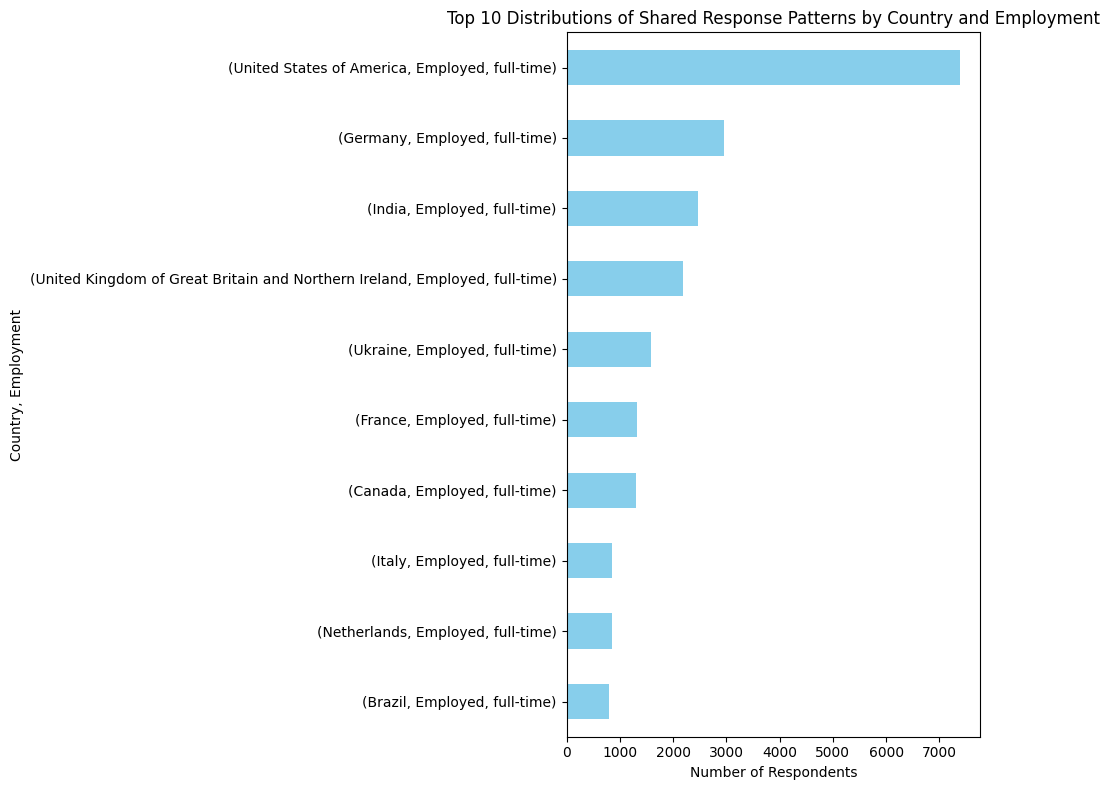

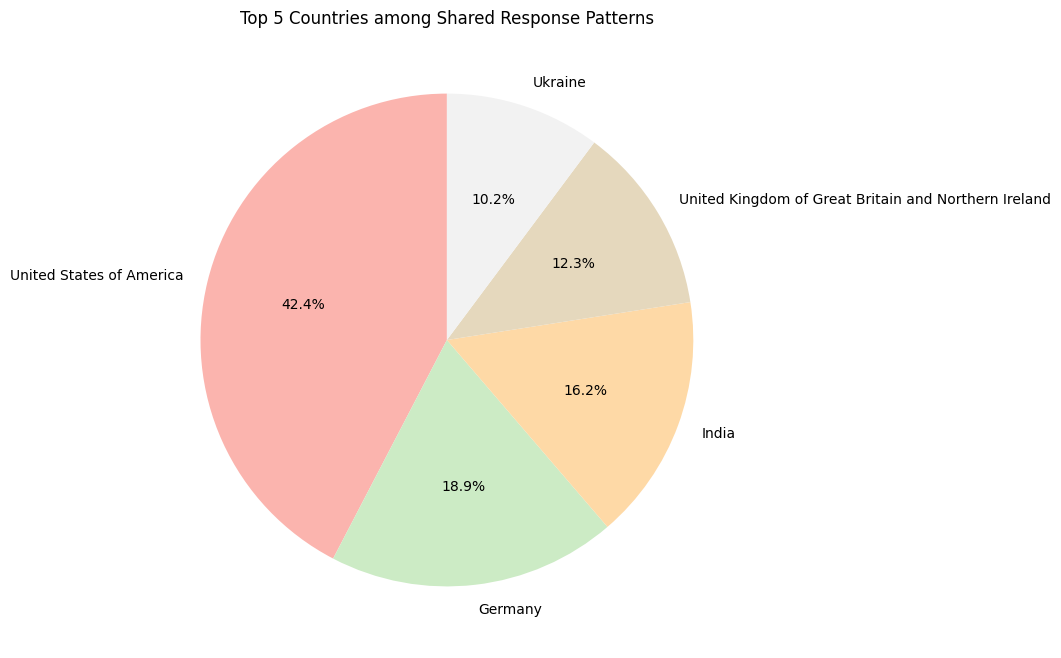

In [32]:
import matplotlib.pyplot as plt

subset = ['MainBranch', 'Employment', 'RemoteWork']
duplicates = df[df.duplicated(subset, keep=False)]

# 1. Group by Country and Employment to see the distribution
grouped_counts = duplicates.groupby(['Country', 'Employment']).size().sort_values(ascending=True).tail(10)

# 2. Create a horizontal bar chart
plt.figure(figsize=(10, 8)) # Made a bit taller to fit labels nicely
grouped_counts.plot(kind='barh', color='skyblue')
plt.title('Top 10 Distributions of Shared Response Patterns by Country and Employment')
plt.xlabel('Number of Respondents')
plt.ylabel('Country, Employment')
plt.tight_layout()
plt.show()

# 3. Create a pie chart for the top 5 countries among these respondents
country_counts = duplicates['Country'].value_counts().head(5)
plt.figure(figsize=(8, 8))
country_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Top 5 Countries among Shared Response Patterns')
plt.ylabel('') # Hides the 'Country' label on the side
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


### Analysis of Duplicate Handling Strategy

##1. Column defining record uniqueness:**
##The column that defines record uniqueness in this dataset is `ResponseId`. In a survey dataset, each row represents a single respondent's answers, and `ResponseId` serves as the unique primary key for each participant.

##2. Appropriateness of removing rows based on a subset of columns:**
##Removing rows based on a subset of columns (such as `MainBranch`, `Employment`, and `RemoteWork`) is **NOT appropriate**. 

##As demonstrated in Task 2, many different respondents can share identical answers to certain questions. If we were to remove duplicates based on a subset of columns, we would accidentally delete valid responses from completely different people (who have different `ResponseId`s). This would artificially skew the survey results and cause massive data loss.

##Conclusion: Duplicates should only be removed based on complete row duplication or based solely on the unique identifier (`ResponseId`). This ensures we only remove accidental double-submissions from the exact same respondent.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


**Process of Identifying and Removing Duplicates:**

1. **Identification:** We used the `df.duplicated()` method to flag identical rows. By appending `.sum()`, we counted the total number of duplicate records in the dataset. We also explored duplication on a subset of columns (like `MainBranch`, `Employment`) to find patterns in identical answers.
2. **Removal:** To clean the dataset, we execute `df.drop_duplicates(inplace=True)`. This function scans for completely identical rows and removes the redundant copies while preserving the first occurrence (`keep='first'`).
3. **Verification:** After removal, we run `df.duplicated().sum()` one last time to confirm the result is `0`, meaning all duplicates have been successfully eliminated.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


**Reasoning behind selecting specific columns for identifying and removing duplicates:**

* **For Identifying Patterns:** We selected columns like `MainBranch`, `Employment`, and `RemoteWork` to identify if respondents from similar backgrounds shared similar working conditions. This helps in understanding data distribution, but not for data cleaning.
* **For Removing Duplicates:** We must either evaluate **all columns** simultaneously, or rely exclusively on a unique identifier column such as **`ResponseId`**. Because `ResponseId` is unique to every single survey participant, two rows with the same `ResponseId` indicate an accidental double-submission by the same person. Removing duplicates based on any other subset of columns would incorrectly delete valid responses from completely different people who simply happened to answer the questions identically.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
